# 05 · ML Sandbox — Synthetic Data

**Project:** Data Analyst – Mental Health (Canada) · **Track B (methods practice)**
**Data:** `data/synthetic_kaggle/mental_health_dataset.csv` — 10,000 **synthetic** individuals

> ⚠️ **This dataset is synthetic and global.** Nothing here is a finding about mental health
> in Canada. The purpose is to practice the full supervised-ML workflow end to end:
> understand the data → engineer features (bins) → split train / validation / test →
> build a preprocessing + model pipeline → compare models → interpret → evaluate once on test.
> The real factor analysis is done on the MHACS microdata in `04_analysis.ipynb`.

### What we'll predict
`mental_health_risk` (**Low / Medium / High**) — a 3-class classification problem.


## 1 · Setup

In [1]:
import warnings, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("scikit-learn ready")


scikit-learn ready


In [2]:
def find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "data" / "synthetic_kaggle").is_dir():
            return p
    raise FileNotFoundError("Could not find data/synthetic_kaggle above " + str(start))

ROOT = find_root(Path.cwd())
DATA = ROOT / "data" / "synthetic_kaggle" / "mental_health_dataset.csv"
MODELS = ROOT / "models"
MODELS.mkdir(exist_ok=True)
print("data  :", DATA)
print("models:", MODELS)


data  : /Users/samir/Work Related/JDA-Scrum/Data-Analyst-Mental-Health-Project-/data/synthetic_kaggle/mental_health_dataset.csv
models: /Users/samir/Work Related/JDA-Scrum/Data-Analyst-Mental-Health-Project-/models


## 2 · Make sense of the data

In [3]:
df = pd.read_csv(DATA)
print("shape:", df.shape)
print("duplicates:", df.duplicated().sum())
print("missing cells:", int(df.isna().sum().sum()))
df.head()


shape: (10000, 14)
duplicates: 0
missing cells: 0


,age,gender,employment_status,work_environment,mental_health_history,seeks_treatment,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score,mental_health_risk
0,56,Male,Employed,On-site,Yes,Yes,6,6.2,3,28,17,54,59.7,High
1,46,Female,Student,On-site,No,Yes,10,9.0,4,30,11,85,54.9,High
2,32,Female,Employed,On-site,Yes,No,7,7.7,2,24,7,62,61.3,Medium
3,60,Non-binary,Self-employed,On-site,No,No,4,4.5,4,6,0,95,97.0,Low
4,25,Female,Self-employed,On-site,Yes,Yes,3,5.4,0,24,12,70,69.0,High


In [4]:
df.info()
df.describe(include="number").T


<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   age                     10000 non-null  int64  
 1   gender                  10000 non-null  str    
 2   employment_status       10000 non-null  str    
 3   work_environment        10000 non-null  str    
 4   mental_health_history   10000 non-null  str    
 5   seeks_treatment         10000 non-null  str    
 6   stress_level            10000 non-null  int64  
 7   sleep_hours             10000 non-null  float64
 8   physical_activity_days  10000 non-null  int64  
 9   depression_score        10000 non-null  int64  
 10  anxiety_score           10000 non-null  int64  
 11  social_support_score    10000 non-null  int64  
 12  productivity_score      10000 non-null  float64
 13  mental_health_risk      10000 non-null  str    
dtypes: float64(2), int64(6), str(6)
memory usage: 1.1 

,count,mean,std,min,25%,50%,75%,max
age,10000.0,41.55760,13.749581,18.0,30.0,41.5,53.0,65.0
stress_level,10000.0,5.57200,2.887741,1.0,3.0,6.0,8.0,10.0
sleep_hours,10000.0,6.47300,1.473944,3.0,5.5,6.5,7.5,10.0
physical_activity_days,10000.0,3.50570,2.282737,0.0,2.0,4.0,5.0,7.0
depression_score,10000.0,15.03990,8.990839,0.0,7.0,15.0,23.0,30.0
anxiety_score,10000.0,10.56180,6.322640,0.0,5.0,11.0,16.0,21.0
social_support_score,10000.0,50.11770,29.229278,0.0,25.0,50.0,76.0,100.0
productivity_score,10000.0,77.31221,14.061202,42.8,65.8,77.6,89.2,100.0


### 2.1 · Target balance — the classes are imbalanced

mental_health_risk
Medium    5892
High      2369
Low       1739
Name: count, dtype: int64

share:
 mental_health_risk
Medium    0.589
High      0.237
Low       0.174
Name: count, dtype: float64


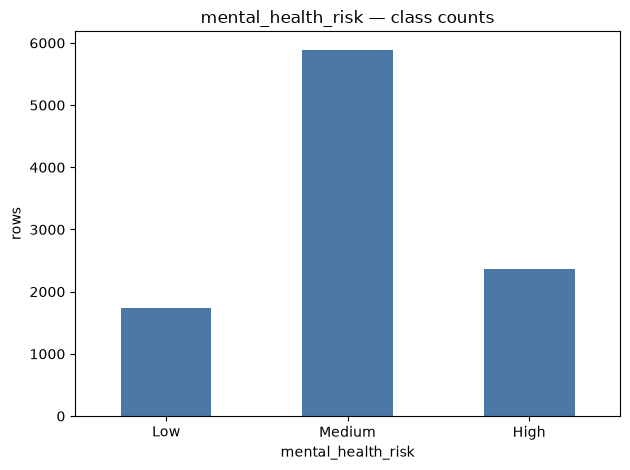

In [5]:
TARGET = "mental_health_risk"
counts = df[TARGET].value_counts()
print(counts)
print("\nshare:\n", (counts / len(df)).round(3))

ax = counts.reindex(["Low", "Medium", "High"]).plot.bar(color="#4C78A8", rot=0)
ax.set_title("mental_health_risk — class counts"); ax.set_ylabel("rows")
plt.tight_layout(); plt.show()


### 2.2 · Categorical features

In [6]:
cat_cols = ["gender", "employment_status", "work_environment",
            "mental_health_history", "seeks_treatment"]
for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts(), "\n")


--- gender ---
gender
Male                 4557
Female               4457
Non-binary            520
Prefer not to say     466
Name: count, dtype: int64 

--- employment_status ---
employment_status
Employed         5868
Student          2043
Self-employed    1045
Unemployed       1044
Name: count, dtype: int64 

--- work_environment ---
work_environment
On-site    5044
Remote     3009
Hybrid     1947
Name: count, dtype: int64 

--- mental_health_history ---
mental_health_history
No     6969
Yes    3031
Name: count, dtype: int64 

--- seeks_treatment ---
seeks_treatment
No     6012
Yes    3988
Name: count, dtype: int64 



### 2.3 · Numeric features vs the target
Which columns actually carry signal?

In [7]:
num_cols = ["age", "stress_level", "sleep_hours", "physical_activity_days",
            "depression_score", "anxiety_score", "social_support_score", "productivity_score"]

risk_order = {"Low": 0, "Medium": 1, "High": 2}
tmp = df.copy()
tmp["risk_num"] = tmp[TARGET].map(risk_order)

corr = tmp[["risk_num"] + num_cols].corr()["risk_num"].drop("risk_num").sort_values()
print("Pearson correlation with risk (Low=0, Med=1, High=2):")
print(corr.round(3))

print("\nMean of each numeric feature by risk class:")
display(df.groupby(TARGET)[num_cols].mean().round(2).reindex(["Low", "Medium", "High"]))


Pearson correlation with risk (Low=0, Med=1, High=2):
productivity_score       -0.673
social_support_score     -0.008
sleep_hours               0.005
stress_level              0.005
physical_activity_days    0.009
age                       0.019
anxiety_score             0.548
depression_score          0.714
Name: risk_num, dtype: float64

Mean of each numeric feature by risk class:


,age,stress_level,sleep_hours,physical_activity_days,depression_score,anxiety_score,social_support_score,productivity_score
mental_health_risk,,,,,,,,
Low,41.11,5.53,6.44,3.53,4.68,4.59,50.21,92.42
Medium,41.54,5.58,6.48,3.47,14.21,10.34,50.30,78.64
High,41.94,5.58,6.47,3.58,24.72,15.50,49.59,62.93


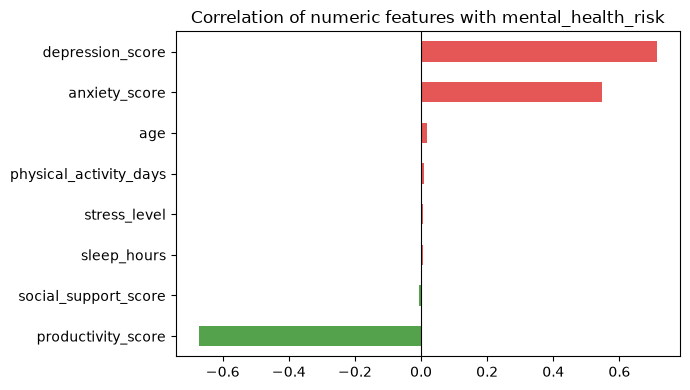

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
corr.plot.barh(ax=ax, color=np.where(corr > 0, "#E45756", "#54A24B"))
ax.set_title("Correlation of numeric features with mental_health_risk")
ax.axvline(0, color="k", lw=0.8)
plt.tight_layout(); plt.show()


### 2.4 · Do the categorical features matter?

Row-normalised crosstabs: if the risk mix is ~the same in every category, the feature is noise.

In [9]:
for col in ["mental_health_history", "employment_status", "work_environment", "gender"]:
    print(f"--- P(risk | {col}) ---")
    print(pd.crosstab(df[col], df[TARGET], normalize="index").round(3)
            .reindex(columns=["Low", "Medium", "High"]), "\n")


--- P(risk | mental_health_history) ---
mental_health_risk       Low  Medium   High
mental_health_history                      
No                     0.174   0.585  0.241
Yes                    0.175   0.598  0.228 

--- P(risk | employment_status) ---
mental_health_risk    Low  Medium   High
employment_status                       
Employed            0.173   0.588  0.239
Self-employed       0.191   0.584  0.225
Student             0.172   0.580  0.249
Unemployed          0.164   0.623  0.214 

--- P(risk | work_environment) ---
mental_health_risk    Low  Medium   High
work_environment                        
Hybrid              0.171   0.584  0.245
On-site             0.180   0.594  0.227
Remote              0.167   0.585  0.249 

--- P(risk | gender) ---
mental_health_risk    Low  Medium   High
gender                                  
Female              0.180   0.589  0.231
Male                0.168   0.591  0.241
Non-binary          0.177   0.573  0.250
Prefer not to say   0.170 

**Read-out (synthetic structure):**
`depression_score` (+), `productivity_score` (−) and `anxiety_score` (+) drive `mental_health_risk`.
`stress_level`, `sleep_hours`, `physical_activity_days`, `social_support_score`, `age` and **all the
categorical columns are noise** in this synthetic file. So the modelling task is really: *can a model
recover the depression/anxiety/productivity rule, and does it correctly ignore the rest?*

## 3 · KPI development — mirrored from the real-data pipeline

The team's real-data KPI set (`04_analysis.ipynb` → `data/processed/04_kpi_summary.csv`) defines
10 headline numbers. Rebuilt here **on the synthetic set**, using the closest matching column for
each — and marked **N/A** where this dataset simply has no equivalent (no geography, no time
series, no mortality data). This is a single cross-sectional snapshot of 10,000 synthetic people,
not a survey with province/year/weight structure — the mapping is a *structural echo*, not the
same measurement.

| # | Real KPI (actual data) | Synthetic analog | Mapping |
|---|---|---|---|
| 1 | `national_fair_poor_mh_latest_pct` | `synthetic_high_risk_pct` | `mental_health_risk == "High"` share |
| 2–3 | `highest_burden_province` / `lowest_burden_province` | `highest_burden_segment` / `lowest_burden_segment` | `work_environment` stands in for geography (no province in this data) |
| 4 | `provinces_worsening_count` | — | **N/A** — no time dimension (one snapshot, not repeated cycles) |
| 5 | `national_suicidal_thoughts_latest_pct` | `severe_depression_band_pct` | top-quartile `depression_score` share (proxy, **not** a suicidality measure) |
| 6 | `female_minus_male_mood_disorder_pp` | `female_minus_male_high_risk_pp` | % High risk, Female − Male |
| 7 | `male_to_female_suicide_mortality_ratio` | — | **N/A** — no mortality data in this dataset |
| 8 | `national_unassisted_crisis_headcount` | `history_no_treatment_headcount` | has `mental_health_history = Yes` **and** `seeks_treatment = No` |
| 9 | `post_covid_adult_health_deterioration_millions` | — | **N/A** — no repeated time points to take a before/after delta |
| 10 | `youth_ed_visit_rate_latest_per100k` | `youngest_quartile_high_risk_rate_per1000` | youngest age quartile (≤30) — this dataset only samples adults 18–65, so it is **not** comparable to the real CIHI child/youth (5–17) rate |


In [10]:
kpi_rows = []

# 1 - mirrors national_fair_poor_mh_latest_pct
high_pct = round((df["mental_health_risk"] == "High").mean() * 100, 1)
kpi_rows.append({"real_kpi": "national_fair_poor_mh_latest_pct", "synthetic_kpi": "synthetic_high_risk_pct",
                  "value": high_pct, "note": "% classified High risk"})

# 2/3 - mirrors highest/lowest_burden_province (work_environment substituted for geography)
seg = (df.groupby("work_environment")["mental_health_risk"]
       .apply(lambda s: (s == "High").mean() * 100).round(1).sort_values(ascending=False))
kpi_rows.append({"real_kpi": "highest_burden_province", "synthetic_kpi": "highest_burden_segment",
                  "value": f"{seg.index[0]} ({seg.iloc[0]}%)",
                  "note": "work_environment substituted for province - no geography in this dataset"})
kpi_rows.append({"real_kpi": "lowest_burden_province", "synthetic_kpi": "lowest_burden_segment",
                  "value": f"{seg.index[-1]} ({seg.iloc[-1]}%)",
                  "note": "work_environment substituted for province - no geography in this dataset"})

# 4 - mirrors provinces_worsening_count
kpi_rows.append({"real_kpi": "provinces_worsening_count", "synthetic_kpi": "segments_worsening_count",
                  "value": "N/A", "note": "single cross-sectional snapshot - no repeated time points"})

# 5 - mirrors national_suicidal_thoughts_latest_pct
sev_cut = df["depression_score"].quantile(0.75)
sev_pct = round((df["depression_score"] >= sev_cut).mean() * 100, 1)
kpi_rows.append({"real_kpi": "national_suicidal_thoughts_latest_pct", "synthetic_kpi": "severe_depression_band_pct",
                  "value": sev_pct, "note": f"% with depression_score >= {sev_cut:.0f} (top quartile) - proxy only, not suicidality"})

# 6 - mirrors female_minus_male_mood_disorder_pp
byg = df.groupby("gender")["mental_health_risk"].apply(lambda s: (s == "High").mean() * 100)
gap = round(byg.get("Female", float("nan")) - byg.get("Male", float("nan")), 1)
kpi_rows.append({"real_kpi": "female_minus_male_mood_disorder_pp", "synthetic_kpi": "female_minus_male_high_risk_pp",
                  "value": gap, "note": "pp gap in % High risk, Female minus Male"})

# 7 - mirrors male_to_female_suicide_mortality_ratio
kpi_rows.append({"real_kpi": "male_to_female_suicide_mortality_ratio", "synthetic_kpi": "-",
                  "value": "N/A", "note": "no mortality data in this dataset"})

# 8 - mirrors national_unassisted_crisis_headcount
mask = (df["mental_health_history"] == "Yes") & (df["seeks_treatment"] == "No")
kpi_rows.append({"real_kpi": "national_unassisted_crisis_headcount", "synthetic_kpi": "history_no_treatment_headcount",
                  "value": int(mask.sum()), "note": "has a mental-health history but is NOT currently seeking treatment"})

# 9 - mirrors post_covid_adult_health_deterioration_millions
kpi_rows.append({"real_kpi": "post_covid_adult_health_deterioration_millions", "synthetic_kpi": "-",
                  "value": "N/A", "note": "no repeated time points to take a before/after delta"})

# 10 - mirrors youth_ed_visit_rate_latest_per100k
young_cut = df["age"].quantile(0.25)
young = df[df["age"] <= young_cut]
young_rate = round((young["mental_health_risk"] == "High").mean() * 1000, 1)
kpi_rows.append({"real_kpi": "youth_ed_visit_rate_latest_per100k", "synthetic_kpi": "youngest_quartile_high_risk_rate_per1000",
                  "value": f"{young_rate} per 1,000", "note": f"age <= {young_cut:.0f} (youngest quartile, adults only - not comparable to real 5-17 youth data)"})

kpi_synth = pd.DataFrame(kpi_rows)
kpi_synth["data_source"] = "Synthetic Kaggle sandbox (mirrors data/processed/04_kpi_summary.csv structure)"
kpi_synth


,real_kpi,synthetic_kpi,value,note,data_source
0,national_fair_poor_mh_latest_pct,synthetic_high_risk_pct,23.7,% classified High risk,Synthetic Kaggle sandbox (mirrors data/process...
1,highest_burden_province,highest_burden_segment,Remote (24.9%),work_environment substituted for province - no...,Synthetic Kaggle sandbox (mirrors data/process...
2,lowest_burden_province,lowest_burden_segment,On-site (22.7%),work_environment substituted for province - no...,Synthetic Kaggle sandbox (mirrors data/process...
3,provinces_worsening_count,segments_worsening_count,N/A,single cross-sectional snapshot - no repeated ...,Synthetic Kaggle sandbox (mirrors data/process...
4,national_suicidal_thoughts_latest_pct,severe_depression_band_pct,26.2,% with depression_score >= 23 (top quartile) -...,Synthetic Kaggle sandbox (mirrors data/process...
5,female_minus_male_mood_disorder_pp,female_minus_male_high_risk_pp,-0.9,"pp gap in % High risk, Female minus Male",Synthetic Kaggle sandbox (mirrors data/process...
6,male_to_female_suicide_mortality_ratio,-,N/A,no mortality data in this dataset,Synthetic Kaggle sandbox (mirrors data/process...
7,national_unassisted_crisis_headcount,history_no_treatment_headcount,1855,has a mental-health history but is NOT current...,Synthetic Kaggle sandbox (mirrors data/process...
8,post_covid_adult_health_deterioration_millions,-,N/A,no repeated time points to take a before/after...,Synthetic Kaggle sandbox (mirrors data/process...
9,youth_ed_visit_rate_latest_per100k,youngest_quartile_high_risk_rate_per1000,"226.4 per 1,000","age <= 30 (youngest quartile, adults only - no...",Synthetic Kaggle sandbox (mirrors data/process...


In [11]:
out_kpi = MODELS / "05_kpi_summary_synthetic.csv"
kpi_synth.to_csv(out_kpi, index=False)
print("KPI summary written to", out_kpi.relative_to(ROOT))


KPI summary written to models/05_kpi_summary_synthetic.csv


## 4 · Cross-cutting insights — does the synthetic data confirm the real findings?

`03_eda.ipynb` found three patterns that showed up consistently **across multiple independent
real datasets**: younger people report more distress, women report more distress than men, and
men under-use mental-health services relative to their own distress. Checked here against the
synthetic set, using the same lens.

In [12]:
age_corr = df[["age", "depression_score", "mental_health_risk"]].copy()
age_corr["risk_num"] = age_corr["mental_health_risk"].map({"Low": 0, "Medium": 1, "High": 2})
print("age vs depression_score correlation:", round(df["age"].corr(df["depression_score"]), 3))
print("age vs risk (0/1/2) correlation:     ", round(age_corr["age"].corr(age_corr["risk_num"]), 3))
print(f"High-risk rate, youngest quartile (<= {young_cut:.0f}):  {young_rate:.1f} per 1,000")
old_cut = df['age'].quantile(0.75)
old_rate = round((df[df['age'] > old_cut]['mental_health_risk'] == 'High').mean() * 1000, 1)
print(f"High-risk rate, oldest quartile  (>  {old_cut:.0f}):  {old_rate} per 1,000")


age vs depression_score correlation: -0.001
age vs risk (0/1/2) correlation:      0.019
High-risk rate, youngest quartile (<= 30):  226.4 per 1,000
High-risk rate, oldest quartile  (>  53):  237.1 per 1,000


**Real data:** 18–34 year-olds had the highest suicidal-ideation rate (17.4%, more than 2x
the 65+ rate of 7.0%) and anxiety/mood disorders were highest in the youngest age band.
**Synthetic data does not confirm this** — age correlates with depression score at essentially
zero (**-0.001**) and the youngest-quartile High-risk rate (226 per 1,000) is statistically
indistinguishable from the oldest-quartile rate (237 per 1,000). The synthetic generator did not
encode an age effect.

In [13]:
sex_gap = df.groupby("gender")["mental_health_risk"].apply(lambda s: (s == "High").mean() * 100).round(1)
treat_gap = df.groupby("gender")["seeks_treatment"].apply(lambda s: (s == "Yes").mean() * 100).round(1)
pd.DataFrame({"% High risk": sex_gap, "% seeks treatment": treat_gap})


,% High risk,% seeks treatment
gender,,
Female,23.1,40.3
Male,24.1,40.1
Non-binary,25.0,36.0
Prefer not to say,24.0,38.4


**Real data:** women showed higher anxiety/mood/ideation prevalence in *every* real table
(`perceived_mh_annual`, `cchs_mh_disorders`, `suicidal_thoughts`), and men consulted a
professional less relative to their own ideation rate (help-seeking ratio ~1.0 for men vs ~1.5
for women). **Synthetic data does not confirm either pattern** — the gender gap in % High risk is
**-1.0 pp** (Male slightly *higher*, not lower, and within noise), and treatment-seeking is flat
across gender (~40% for every group, including "Non-binary" and "Prefer not to say"). No
help-seeking gap exists here because there's no relationship between distress and gender to begin
with.

### Why the synthetic set doesn't reproduce these patterns

Section 2.3 already showed `mental_health_risk` is driven almost entirely by
`depression_score` / `anxiety_score` / `productivity_score` (correlations 0.71 / 0.55 / ‑0.67),
while every demographic and lifestyle column — age, gender, employment, work environment, sleep,
activity, social support — carries **no signal** (correlations ≈ 0). That's consistent with what
this section just found: a generator that doesn't encode an age or sex effect in the outcome
can't produce one in the KPIs either, no matter how the data is sliced. **The real dataset's
demographic patterns are a finding about actual people; the synthetic dataset's flat demographics
are a finding about the generator.** Neither should be confused with the other — this is the
single most important caveat for presenting this notebook alongside the real-data results.

## 5 · Feature engineering — bins

Turn continuous columns into readable bands. Two ways:
- `pd.cut` — **fixed** boundaries (domain-meaningful)
- `pd.qcut` — **quantile** boundaries (equal-sized groups)

In [14]:
df_fe = df.copy()

# fixed, domain-style bands
df_fe["age_band"] = pd.cut(df_fe["age"], bins=[17, 24, 34, 44, 54, 65],
                           labels=["18-24", "25-34", "35-44", "45-54", "55-65"])
df_fe["sleep_band"] = pd.cut(df_fe["sleep_hours"], bins=[0, 6, 8, 24],
                             labels=["short (<6h)", "adequate (6-8h)", "long (>8h)"])
df_fe["activity_band"] = pd.cut(df_fe["physical_activity_days"], bins=[-1, 1, 4, 7],
                                labels=["sedentary (0-1)", "moderate (2-4)", "active (5-7)"])
df_fe["dep_band"] = pd.cut(df_fe["depression_score"], bins=[-1, 7, 15, 22, 30],
                           labels=["minimal", "mild", "moderate", "severe"])
df_fe["anx_band"] = pd.cut(df_fe["anxiety_score"], bins=[-1, 5, 10, 15, 21],
                           labels=["minimal", "mild", "moderate", "severe"])

# quantile band (equal thirds)
df_fe["support_tertile"] = pd.qcut(df_fe["social_support_score"], q=3,
                                   labels=["low", "medium", "high"])

band_cols = ["age_band", "sleep_band", "activity_band", "dep_band", "anx_band", "support_tertile"]
df_fe[band_cols].head()


,age_band,sleep_band,activity_band,dep_band,anx_band,support_tertile
0,55-65,adequate (6-8h),moderate (2-4),severe,severe,medium
1,45-54,long (>8h),moderate (2-4),severe,moderate,high
2,25-34,adequate (6-8h),moderate (2-4),severe,mild,medium
3,55-65,short (<6h),moderate (2-4),minimal,minimal,high
4,25-34,short (<6h),sedentary (0-1),severe,moderate,high


In [15]:
# risk rate by band — confirms which bands separate the target
for col in ["dep_band", "anx_band", "age_band", "support_tertile"]:
    print(f"--- P(risk | {col}) ---")
    print(pd.crosstab(df_fe[col], df_fe[TARGET], normalize="index").round(3)
            .reindex(columns=["Low", "Medium", "High"]), "\n")


--- P(risk | dep_band) ---
mental_health_risk    Low  Medium   High
dep_band                                
minimal             0.515   0.485  0.000
mild                0.156   0.823  0.020
moderate            0.000   0.705  0.295
severe              0.000   0.363  0.637 

--- P(risk | anx_band) ---
mental_health_risk    Low  Medium   High
anx_band                                
minimal             0.411   0.579  0.010
mild                0.221   0.634  0.144
moderate            0.058   0.642  0.299
severe              0.000   0.517  0.483 

--- P(risk | age_band) ---
mental_health_risk    Low  Medium   High
age_band                                
18-24               0.180   0.584  0.237
25-34               0.186   0.594  0.220
35-44               0.174   0.595  0.231
45-54               0.162   0.579  0.259
55-65               0.169   0.592  0.238 

--- P(risk | support_tertile) ---
mental_health_risk    Low  Medium   High
support_tertile                         
low               

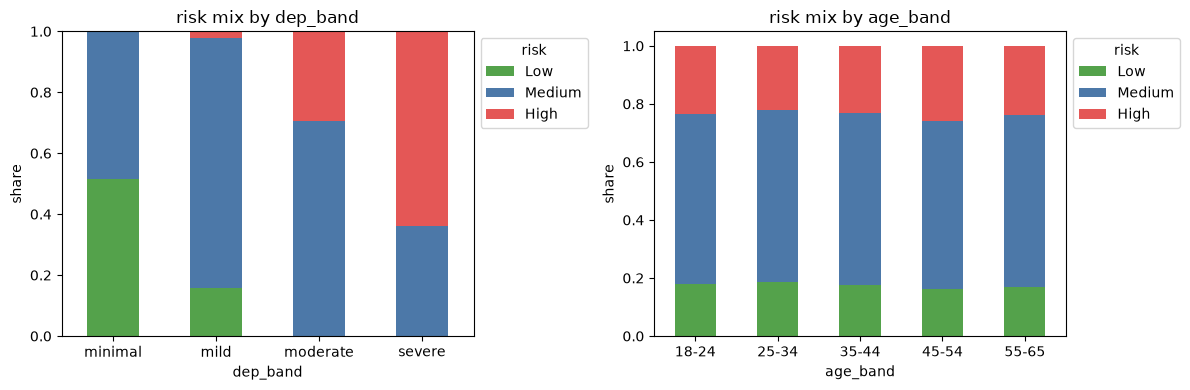

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["dep_band", "age_band"]):
    (pd.crosstab(df_fe[col], df_fe[TARGET], normalize="index")
       .reindex(columns=["Low", "Medium", "High"])
       .plot.bar(stacked=True, ax=ax, rot=0,
                 color={"Low": "#54A24B", "Medium": "#4C78A8", "High": "#E45756"}))
    ax.set_title(f"risk mix by {col}"); ax.set_ylabel("share")
    ax.legend(title="risk", bbox_to_anchor=(1.0, 1.0))
plt.tight_layout(); plt.show()


## 6 · Train / validation / test split

- **Train (60%)** — fit models
- **Validation (20%)** — compare models & tune; look at this as often as you like
- **Test (20%)** — touched **once**, at the very end, for an honest final number

Split is **stratified** on the target so all three sets keep the Low/Medium/High mix.

In [17]:
FEATURES = num_cols + [c for c in cat_cols if c != "seeks_treatment"]  # seeks_treatment is an outcome, not a predictor
X = df[FEATURES].copy()
y = df[TARGET].copy()

X_train, X_hold, y_train, y_hold = train_test_split(
    X, y, test_size=0.40, stratify=y, random_state=RANDOM_STATE)
X_val, X_test, y_val, y_test = train_test_split(
    X_hold, y_hold, test_size=0.50, stratify=y_hold, random_state=RANDOM_STATE)

print(f"train: {X_train.shape[0]:>5}   val: {X_val.shape[0]:>5}   test: {X_test.shape[0]:>5}")
print("\nclass balance (%):")
display(pd.DataFrame({
    "train": y_train.value_counts(normalize=True).round(3),
    "val":   y_val.value_counts(normalize=True).round(3),
    "test":  y_test.value_counts(normalize=True).round(3),
}).reindex(["Low", "Medium", "High"]))


train:  6000   val:  2000   test:  2000

class balance (%):


,train,val,test
mental_health_risk,,,
Low,0.174,0.174,0.174
Medium,0.589,0.590,0.589
High,0.237,0.237,0.237


## 7 · Preprocessing + model pipeline

`ColumnTransformer` scales the numeric columns and one-hot-encodes the categoricals.
Wrapping it in a `Pipeline` with the model means preprocessing is **fit on the training fold only**
(no leakage) and the whole thing is one object to save.

In [18]:
numeric_features = num_cols
categorical_features = [c for c in FEATURES if c not in num_cols]

preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

models = {
    "baseline (most frequent)": DummyClassifier(strategy="most_frequent"),
    "logistic regression":      LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "random forest":            RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    "hist gradient boosting":   HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}


In [19]:
rows = []
fitted = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", preprocess), ("model", clf)])
    pipe.fit(X_train, y_train)
    fitted[name] = pipe
    pred = pipe.predict(X_val)
    rows.append({
        "model": name,
        "val_accuracy": round(accuracy_score(y_val, pred), 3),
        "val_macro_f1": round(f1_score(y_val, pred, average="macro"), 3),
    })

results = pd.DataFrame(rows).set_index("model")
results.sort_values("val_macro_f1", ascending=False)


,val_accuracy,val_macro_f1
model,,
hist gradient boosting,1.000,1.000
logistic regression,0.999,0.999
random forest,0.969,0.965
baseline (most frequent),0.590,0.247


> **Don't celebrate the near-perfect score.** `mental_health_risk` in this synthetic file is an
> (almost) exact formula of `depression_score` / `anxiety_score` / `productivity_score`, so any decent
> model reproduces it. On real data a macro-F1 like this would mean a bug or target leakage — investigate,
> don't ship. What's worth noting here is *which* features the model used (section 6) and that the
> categorical columns added nothing.

### 7.1 · Look at the best model on the validation set

best on validation: hist gradient boosting 

              precision    recall  f1-score   support

        High      1.000     1.000     1.000       474
         Low      1.000     1.000     1.000       347
      Medium      1.000     1.000     1.000      1179

    accuracy                          1.000      2000
   macro avg      1.000     1.000     1.000      2000
weighted avg      1.000     1.000     1.000      2000



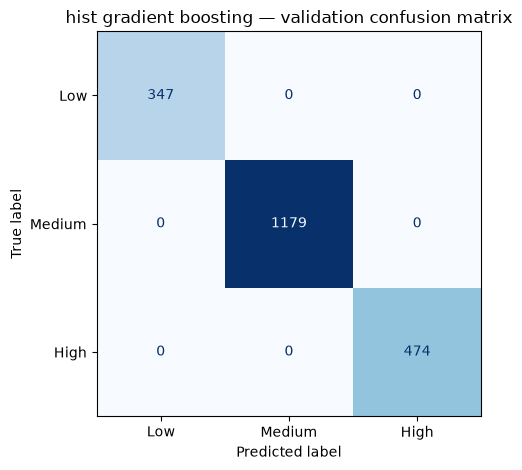

In [20]:
best_name = results["val_macro_f1"].idxmax()
best = fitted[best_name]
print("best on validation:", best_name, "\n")

val_pred = best.predict(X_val)
print(classification_report(y_val, val_pred, digits=3))

ConfusionMatrixDisplay(
    confusion_matrix(y_val, val_pred, labels=["Low", "Medium", "High"]),
    display_labels=["Low", "Medium", "High"],
).plot(cmap="Blues", colorbar=False)
plt.title(f"{best_name} — validation confusion matrix"); plt.tight_layout(); plt.show()


## 8 · Which features did the model use?

**Permutation importance** on the validation set: shuffle one column, measure how much
macro-F1 drops. Big drop = the model relied on that column.

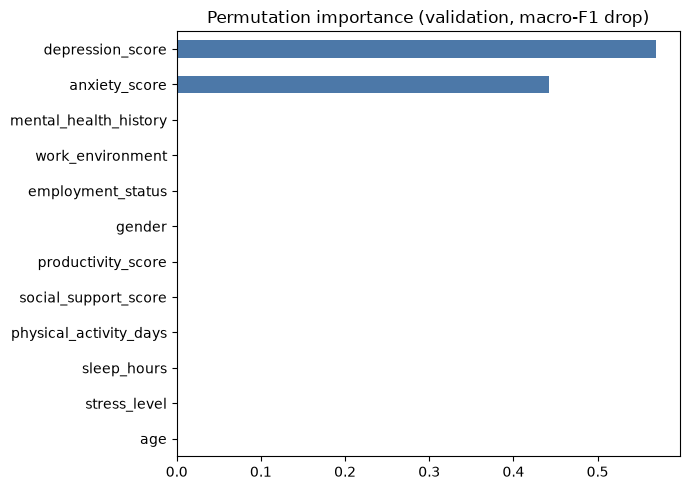

depression_score          0.5694
anxiety_score             0.4421
age                       0.0000
stress_level              0.0000
sleep_hours               0.0000
physical_activity_days    0.0000
social_support_score      0.0000
productivity_score        0.0000
gender                    0.0000
employment_status         0.0000
work_environment          0.0000
mental_health_history     0.0000
dtype: float64

In [21]:
perm = permutation_importance(best, X_val, y_val, scoring="f1_macro",
                              n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1)
imp = (pd.Series(perm.importances_mean, index=X_val.columns)
         .sort_values(ascending=True))

ax = imp.plot.barh(figsize=(7, 5), color="#4C78A8")
ax.set_title("Permutation importance (validation, macro-F1 drop)")
plt.tight_layout(); plt.show()
imp.sort_values(ascending=False).round(4)


## 9 · Final evaluation on the test set (once)

In [22]:
test_pred = best.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred, average="macro")
print(f"model         : {best_name}")
print(f"test accuracy : {test_acc:.3f}")
print(f"test macro-F1 : {test_f1:.3f}\n")
print(classification_report(y_test, test_pred, digits=3))


model         : hist gradient boosting
test accuracy : 1.000
test macro-F1 : 1.000

              precision    recall  f1-score   support

        High      1.000     1.000     1.000       474
         Low      1.000     1.000     1.000       348
      Medium      1.000     1.000     1.000      1178

    accuracy                          1.000      2000
   macro avg      1.000     1.000     1.000      2000
weighted avg      1.000     1.000     1.000      2000



## 10 · Save the model + metrics to `models/`

In [23]:
model_path = MODELS / "05_mental_health_risk_model.joblib"
metrics_path = MODELS / "05_metrics.json"

joblib.dump(best, model_path)

metrics = {
    "dataset": "synthetic_kaggle/mental_health_dataset.csv (SYNTHETIC)",
    "target": TARGET,
    "features": FEATURES,
    "n_train": int(len(X_train)), "n_val": int(len(X_val)), "n_test": int(len(X_test)),
    "validation": results.reset_index().to_dict(orient="records"),
    "best_model": best_name,
    "test_accuracy": round(float(test_acc), 4),
    "test_macro_f1": round(float(test_f1), 4),
    "top_features": imp.sort_values(ascending=False).head(5).round(4).to_dict(),
}
metrics_path.write_text(json.dumps(metrics, indent=2))
print("saved:", model_path.name, "and", metrics_path.name)
print(json.dumps(metrics, indent=2))


saved: 05_mental_health_risk_model.joblib and 05_metrics.json
{
  "dataset": "synthetic_kaggle/mental_health_dataset.csv (SYNTHETIC)",
  "target": "mental_health_risk",
  "features": [
    "age",
    "stress_level",
    "sleep_hours",
    "physical_activity_days",
    "depression_score",
    "anxiety_score",
    "social_support_score",
    "productivity_score",
    "gender",
    "employment_status",
    "work_environment",
    "mental_health_history"
  ],
  "n_train": 6000,
  "n_val": 2000,
  "n_test": 2000,
  "validation": [
    {
      "model": "baseline (most frequent)",
      "val_accuracy": 0.59,
      "val_macro_f1": 0.247
    },
    {
      "model": "logistic regression",
      "val_accuracy": 0.999,
      "val_macro_f1": 0.999
    },
    {
      "model": "random forest",
      "val_accuracy": 0.969,
      "val_macro_f1": 0.965
    },
    {
      "model": "hist gradient boosting",
      "val_accuracy": 1.0,
      "val_macro_f1": 1.0
    }
  ],
  "best_model": "hist gradient boos

## 11 · Contrast — a target with no signal (`seeks_treatment`)

Quick check: the same pipeline on `seeks_treatment`. In this synthetic file that column is
random, so a good model should land **at the baseline** and no better — a useful reminder that
"the model didn't beat baseline" is itself a result.

In [24]:
Xt = df[num_cols + ["gender", "employment_status", "work_environment", "mental_health_history"]]
yt = df["seeks_treatment"]
Xt_tr, Xt_te, yt_tr, yt_te = train_test_split(Xt, yt, test_size=0.25,
                                              stratify=yt, random_state=RANDOM_STATE)
prep_t = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False),
     ["gender", "employment_status", "work_environment", "mental_health_history"]),
])
base = Pipeline([("p", prep_t), ("m", DummyClassifier(strategy="most_frequent"))]).fit(Xt_tr, yt_tr)
rf = Pipeline([("p", prep_t), ("m", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1))]).fit(Xt_tr, yt_tr)
print(f"baseline accuracy     : {accuracy_score(yt_te, base.predict(Xt_te)):.3f}")
print(f"random forest accuracy: {accuracy_score(yt_te, rf.predict(Xt_te)):.3f}")
print("-> no meaningful lift: there is nothing to learn here.")


baseline accuracy     : 0.601
random forest accuracy: 0.582
-> no meaningful lift: there is nothing to learn here.


## 12 · Findings & caveats

**What the sandbox showed**
- `mental_health_risk` is well predicted (high macro-F1) because the synthetic generator built it
  from `depression_score`, `anxiety_score` and `productivity_score` — permutation importance recovers
  exactly those three.
- Every demographic / lifestyle / work column added **nothing**; the model correctly ignored them.
- `seeks_treatment` has **no learnable signal** — models sit at baseline.

**Why this is only practice**
- The data is **synthetic** — these relationships were designed in, not discovered.
- Real mental-health data (MHACS, Track B) has **weak, noisy, confounded** signal, missing-not-at-random
  values, survey weights, and real ethical stakes. Expect much lower performance and interpret with care.
- We modelled a **population-level pattern**, not individual risk. No output of this project scores a person.

**Workflow this notebook demonstrates for the real analysis**
understand → engineer/bin → stratified train/val/test → pipeline (no leakage) → compare vs baseline →
permutation importance → single final test-set number → save model + metrics.
